In [1]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [55]:
from pycbc.waveform import get_td_waveform, get_fd_waveform
from pycbc.inject import InjectionSet
from pycbc.psd import EinsteinTelescopeP1600143
from pycbc.filter import sigma

In [5]:
t = InjectionSet("m1_480_m2_120_z_7.hdf")
for i, inj in enumerate(t.table):
    pass
delta_t = 0.001953125
f_l = 3

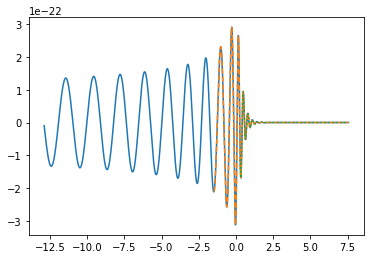

In [6]:
inj.approximant = "SEOBNRv2"
for __fl, ls in zip([0.5, 1, 3], ["-", "--", ":"]):
    hp, hc = get_td_waveform(inj, delta_t=delta_t, f_lower=__fl, f_final=256)
    plot(hp.sample_times, hp, ls=ls, label=__fl)

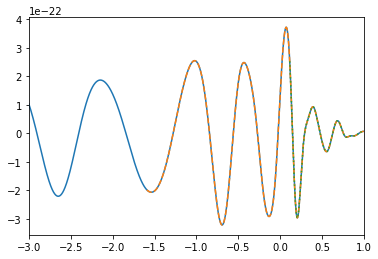

In [8]:
inj.approximant = "SEOBNRv4HM"
for __fl, ls in zip([0.5, 1, 3], ["-", "--", ":"]):
    hp, hc = get_td_waveform(inj, delta_t=delta_t, f_lower=__fl, f_final=256)
    plot(hp.sample_times, hp, ls=ls, label=__fl)
    xlim(-3, 1)

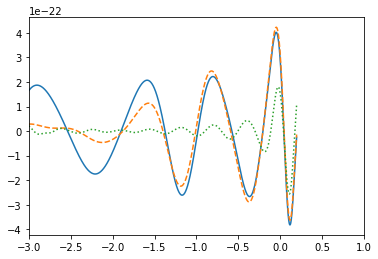

In [15]:
inj.approximant = "IMRPhenomXHM"
for __fl, ls in zip([0.5, 1, 3], ["-", "--", ":"]):
    hp, hc = get_td_waveform(inj, delta_t=delta_t, f_lower=__fl, f_final=256)
    plot(hp.sample_times, hp, ls=ls, label=__fl)
    xlim(-3, 1)

In [17]:
from eventhm import eventhm

In [20]:
from pycbc.waveform import mode_array_map

In [21]:
mode_array_map("22", inj.approximant)

[[2, 2], [2, -2]]

In [ ]:
hp.to_frequencyseries()

19.641237844914162
19.661153061141533
19.98667418892256


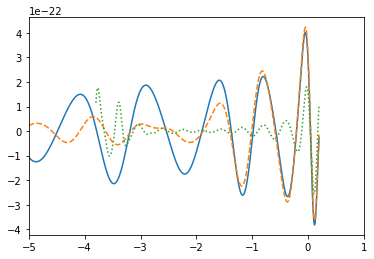

In [68]:
inj.approximant = "IMRPhenomXHM"
for __fl, ls in zip([0.5, 1, 3], ["-", "--", ":"]):
    lm = "44"
    mode_array = mode_array_map(lm, inj.approximant)
    mode_array=None
    hp, hc = get_td_waveform(inj, delta_t=delta_t, f_lower=__fl, f_final=256, 
                             mode_array=mode_array)
    plot(hp.sample_times, hp, ls=ls, label=__fl)
#     hp = hp.to_frequencyseries(delta_f)
    psd = EinsteinTelescopeP1600143(int(fh / hp.delta_f) + 1, hp.delta_f, 3)
    print(sigma(hp, psd=psd, low_frequency_cutoff=3))
#     xlim(-3, 1)
    xlim(-5, 1)    

In [59]:
delta_f = 0.25
fh = 256
length = int(fh/delta_f) + 1 

In [60]:
psd = EinsteinTelescopeP1600143(length, delta_f, 3)

0.0 21.44012351606635
0.06 21.211974460600924
0.13 20.976726337982548
0.19 20.7350660444876
0.25 20.487717653268444
0.32 20.235443560780624
0.38 19.979045626195163
0.44 19.71936625863072
0.51 19.45728939593073
0.57 19.19374130603204
0.63 18.929691127772287
0.7 18.66615105245725
0.76 18.404176031048983
0.83 18.144862875094507
0.89 17.88934860349238
0.95 17.638807873294944
1.02 17.394449322841005
1.08 17.157510651961772
1.14 16.929252269604092
1.21 16.710949357075734
1.27 16.503882228383787
1.33 16.30932492059145
1.4 16.128532018592118
1.46 15.962723810396843
1.52 15.813069978776776
1.59 15.680672157721949
1.65 15.566545809152082
1.71 15.47160199495272
1.78 15.396629717721542
1.84 15.34227956591447
1.9 15.309049412275717
1.97 15.297272869524642
2.03 15.307111101669511
2.09 15.338548428276898
2.16 15.391391955704357
2.22 15.465275243263784
2.28 15.559665786602467
2.35 15.673875898199563
2.41 15.807076404945231
2.48 15.95831247793299
2.54 16.12652086459619
2.6 16.31054780521505
2.67 16.509

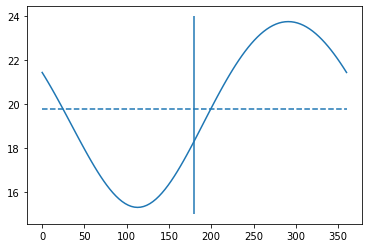

In [100]:
snrs = []
phases = linspace(0,2*pi, 100)
for phase in phases:
    inj.coa_phase = phase
    lm = ["44", "33", "22"]
    mode_array = mode_array_map(lm, inj.approximant)
#     mode_array = None
    hp, hc = get_fd_waveform(inj, delta_f=delta_f, f_lower=__fl, f_final=fh, 
                             mode_array=mode_array)
    s=sigma(hp, psd=psd, low_frequency_cutoff=3)
    print(round(phase, 2), s)
    snrs.append(s)
    hp = hp.to_timeseries()
#     plot(hp.sample_times, hp, ls=ls, label=__fl)
#     plt.show()
plot(degrees(phases), snrs)
hlines(mean(snrs), 0, degrees(2*pi), ls="--")
vlines(degrees(pi), 15, 24)

19.986674188922574
19.986674188922574
19.986674188922574


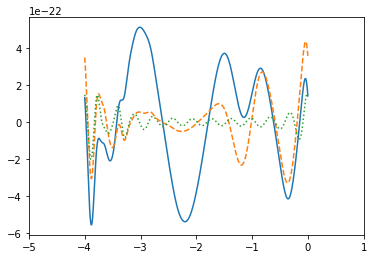

In [69]:
inj.approximant = "IMRPhenomXHM"
for __fl, ls in zip([0.5, 1, 3], ["-", "--", ":"]):
    lm = "44"
    mode_array = mode_array_map(lm, inj.approximant)
#     mode_array=None
    hp, hc = get_fd_waveform(inj, delta_f=delta_f, f_lower=__fl, f_final=fh, 
                             mode_array=mode_array)
    hp = hp.to_timeseries()
    plot(hp.sample_times, hp, ls=ls, label=__fl)
    print(sigma(hp, psd=psd, low_frequency_cutoff=3))
#     xlim(-3, 1)
    xlim(-5, 1)    

Strange.

* it seems that if calculated in the frequency domain the waveform looks very different after a ifft than the one returned directly in the TD
* However these differences don't manifest in SNR differences.
* It seems the waveform is wrapping; but perhaps this also isn't so significant as it doesn't seem to affect the SNR so much.